# A shell inside a curved cavity — coupling two meshes that share no node

`Geom/Vibro_ac1.step` holds a sphere with a cylinder cut out of it, and the
cylinder itself. The intended model is the obvious one: air in the sphere, a
thin metal shell on the cylinder, the two coupled.

That model cannot be meshed the way the other examples are. pyCAFE assembles
shells as **CQUAD4F quadrilaterals** and volumes as **CHEXA8 or CTETRA4**, and
the conforming coupling needs the shell elements to *be* faces of the fluid
elements. A sphere is not a six-sided solid, so it cannot be meshed
transfinitely into hexahedra; the fluid comes out tetrahedral, and the faces of
a tetrahedron are triangles, which no shell kernel here can use. Asking Gmsh
for quadrilaterals on that surface only inserts pyramids, which have no kernel
either.

So the two domains are meshed **separately** — tetrahedra for the fluid,
quadrilaterals for the shell — and merged into one file whose interface shares
no node at all. The coupling is then built by the interpolation method of

> Y. Mi, H. Zheng, *An interpolation method for coupling non-conforming patches
> in isogeometric analysis of vibro-acoustic systems*, Comput. Methods Appl.
> Mech. Engrg. 338 (2018) 264–297.

**STEP → two meshes → merge → interpolated coupling → verification against a
conforming model → shell in vacuo, cavity alone, coupled → forced response.**

In [1]:
import os
import sys
import time
import warnings

sys.path.insert(0, os.path.abspath(".."))            # run from examples/

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.sparse.linalg import eigsh

from pycafe.core.model_spec import (
    AIR, CadFile, ModelSpec, Structure, build_mesh, build_model, preview,
)
from pycafe.create_geom import inspect_cad
from pycafe.solver.solver_vibroacoustic import (
    build_coupled_blocks,
    expand_pressure,
    solve_vibroacoustic_frequency_sweep,
    solve_vibroacoustic_modal,
    structural_displacement_field,
)
from pycafe.solver.solver_vibroacoustic_modal import (
    build_coupled_modal_basis,
    solve_coupled_modal_frequency_sweep,
)

STEP = "../Geom/Vibro_ac1.step"

# Entity tags, read from inspect_cad below.
SPHERE = [1]                                   # the fluid volume
SPHERE_SKIN = [1, 2, 3, 4, 5, 6, 7, 8]         # its outer surface, in octants
CYLINDER_SIDE = [9, 10, 13, 14, 15, 17, 18, 20]   # the shell

RHO0, C0 = AIR.rho0, AIR.c0

# A 5 mm cylinder of 1 mm aluminium would resonate near 50 kHz, far above
# anything the 60 mm cavity does. A thin polymer film brings the shell down
# by an order of magnitude, but not into the cavity band: its first mode
# still lands well above the first cavity mode, as section 6 shows. This
# case is about the interface treatment, not about a strongly coupled pair
# -- and section 6 says why the geometry cannot give one.
SHELL = Structure(t=0.2e-3, E=3.0e9, nu=0.40, rho_s=1200.0,
                  support="clamped", name="polymer film")
F_MAX = 4000.0

plt.rcParams["figure.dpi"] = 110


## 1. What is in the STEP file

A CAD file carries no roles, so the first move is always the same: list what is
inside it and read the tags off the table.

In [2]:
entities = inspect_cad(STEP, units="mm")

sphere, cylinder = entities[3][0], entities[3][1]
print()
print(f"sphere volume   {sphere.size:.4e} m3   "
      f"(a full sphere of the same bbox would be "
      f"{np.pi / 6 * (sphere.bbox_max - sphere.bbox_min).prod():.4e})")
print(f"cylinder volume {cylinder.size:.4e} m3")
print()
print("The difference is exactly the cylinder: the sphere is drawn with the")
print("cylinder already cut out of it, so the two solids touch on a common")
print("surface -- the wet side of the shell.")
print()
print("Units: the largest number in the file is 60. 'auto' would read that as")
print("metres (it only switches to millimetres above 100), so the unit is")
print("stated explicitly: units='mm' -> a 60 mm sphere around a 10 x 20 mm")
print("cylinder.")

../Geom/Vibro_ac1.step  (scaled by 0.001 to metres)
  dim 3  tag    1   volume 1.115e-04   bbox 0.060 x 0.060 x 0.085   centre (-0.000, -0.000, 0.000)
  dim 3  tag    2   volume 1.571e-06   bbox 0.010 x 0.010 x 0.020   centre (0.000, -0.000, 0.000)
  dim 2  tag    1   area   1.414e-03   bbox 0.045 x 0.045 x 0.042   centre (0.015, 0.015, 0.015)
  dim 2  tag    5   area   1.414e-03   bbox 0.045 x 0.045 x 0.042   centre (-0.015, 0.015, 0.015)
  dim 2  tag    3   area   1.414e-03   bbox 0.045 x 0.045 x 0.042   centre (0.015, -0.015, 0.015)
  dim 2  tag    7   area   1.414e-03   bbox 0.045 x 0.045 x 0.042   centre (-0.015, -0.015, 0.015)
  dim 2  tag    8   area   1.414e-03   bbox 0.045 x 0.045 x 0.042   centre (-0.015, -0.015, -0.015)
  dim 2  tag    4   area   1.414e-03   bbox 0.045 x 0.045 x 0.042   centre (0.015, -0.015, -0.015)
  dim 2  tag    6   area   1.414e-03   bbox 0.045 x 0.045 x 0.042   centre (-0.015, 0.015, -0.015)
  dim 2  tag    2   area   1.414e-03   bbox 0.045 x 0.045 x 0

## 2. Why one mesh cannot serve both domains

Meshed in a single pass, this geometry gives what the validator says below.
`_try_structured` looks for six-sided volumes with four-sided faces — the shape
a transfinite hexahedral mesh needs — and a sphere has eight faces, so the
volume falls back to tetrahedra. With `recombine=True` on top of that, Gmsh
puts quadrilaterals on the surfaces and fills the gap with **pyramids**, which
pyCAFE has no kernel for: the fluid would be assembled with holes in it.

In [3]:
single_pass = ModelSpec(
    geometry=CadFile(STEP, units="mm", recombine=True,
                     fluid=SPHERE, structure=CYLINDER_SIDE,
                     boundaries={"outer": SPHERE_SKIN}),
    fluid=AIR, structure=SHELL,
    f_max=1500.0, work_dir=".", output_path="shell_cavity_single.msh",
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    try:
        build_mesh(single_pass)
    except RuntimeError as exc:
        print(exc)

## 3. Two meshes, one file

`independent_structure=True` runs two meshing passes on the same CAD file:

1. the **fluid** alone, unstructured, tetrahedral (`recombine=False`, so no
   pyramids are created);
2. the **shell** alone, recombined into quadrilaterals and transfinite where
   the patch has four sides.

The two are then merged by `pycafe.create_geom.merge.merge_meshes`, which
renumbers the second set of nodes so that **nothing is shared**. That is not an
accident to be repaired later: the two surfaces are the same surface described
twice, and the coupling is what reconciles them.

The mesh size still comes from `f_max`. The unstructured mesher overshoots the
size it is given on a curved boundary, so the density is asked with
`elements_per_wavelength=20` and the validator is left to report what was
actually obtained on the largest element.

**The geometry is drawn before anything is assembled** — `preview` meshes,
validates and plots, and nothing else.

In [4]:
spec = ModelSpec(
    geometry=CadFile(
        STEP, units="mm", recombine=False,
        fluid=SPHERE,
        structure=CYLINDER_SIDE,
        boundaries={"outer": SPHERE_SKIN},
        independent_structure=True,      # two passes, merged
        structure_element_size=3.0e-3,   # the shell can be finer than the air
    ),
    fluid=AIR,
    structure=SHELL,
    f_max=F_MAX,
    elements_per_wavelength=20,
    work_dir=".", output_path="shell_cavity.msh",
)
print(spec.describe())

ModelSpec
  geometry     CadFile(path=PosixPath('../Geom/Vibro_ac1.step'), fluid=[1], structure=[9, 10, 13, 14, 15, 17, 18, 20], clamp='auto', boundaries={'outer': [1, 2, 3, 4, 5, 6, 7, 8]}, walls='rigid_walls', units='mm', dim=3, recombine=False, independent_structure=True, structure_element_size=0.003)
  fluid        air: rho0 = 1.204 kg/m3, c0 = 343.0 m/s
  structure    polymer film: t = 0.20 mm, E = 3 GPa, nu = 0.4, rho = 1200.0 kg/m3, clamped
  f_max        4000.0 Hz (lambda = 86 mm)
  mesh size    4.3 mm (20 elements per wavelength)
  mesh file    shell_cavity.msh
  bending      lambda_b = 13 mm at f_max  (shorter than the acoustic one: check the panel mesh)


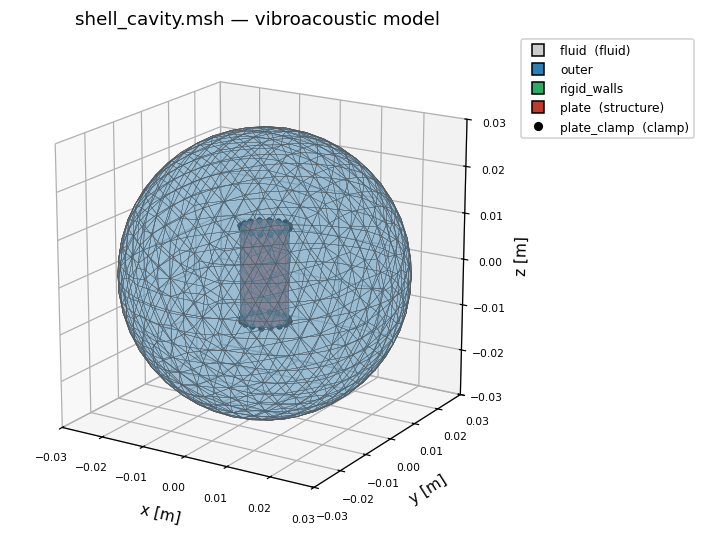

shell_cavity.msh  (vibroacoustic analysis)
------------------------------------------
  1968 nodes, 64 x Line 2, 1828 x Triangle 3, 300 x Quadrilateral 4, 6994 x Tetrahedron 4
  roles: fluid = 'fluid', structure = 'plate', clamp = 'plate_clamp'
  · fluid element size: 3.5 / 6.1 / 8.4 mm (min / mean / max)
  · good to ~1% up to 3139 Hz (13 elements per wavelength at c0 = 343 m/s)
  · at 4000 Hz: 10.2 elements per wavelength, dispersion error ~1.58%
  · selectable boundaries: outer, rigid_walls
  => usable


In [5]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    mesh_path, mesh_report = preview(spec, elev=18, azim=-58, figsize=(11, 5))

The two warnings about the interface are the point of this notebook, not a
problem to fix: the mesh is *usable*, and says how the coupling will be built.

## 4. Assemble — and look at what the interpolation did

`build_model` assembles both domains and the coupling. Finding the interface
non-conforming, it follows §3.3 of the paper:

1. a **virtual layer of acoustic nodes** is laid on the shell grid, so the
   ordinary coupling integral $\mathbf K_c^v = \int_S \mathbf N_s^T \mathbf n
   \mathbf N_a\, dS$ can be assembled on the shell faces as usual;
2. an interpolation matrix $\mathbf A$ writes the pressures of that layer in
   terms of the real fluid ones, from Euclidean distances only;
3. $\mathbf K_c = \mathbf K_c^v \mathbf A$.

The check that has to hold whatever the two grids are: a **uniform pressure**
must produce the same nodal load as the conforming integral alone. That is what
`consistency["relative_error"]` measures.

In [6]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model = build_model(spec, show=False)     # already previewed above

nodes = model["nodes"]
groups = model["groups"]
system = model["system"]

interp = system["coupling"]["nonconforming"]["interpolation"]
consistency = system["coupling"]["nonconforming"]["consistency"]

print(f"conforming interface        {system['interface']['conforming']}")
print(f"fluid nodes on the wet skin {interp['n_master']:5d}   (centres, master)")
print(f"shell nodes                 {interp['n_slave']:5d}   (evaluations, slave)")
print(f"method                      {interp['method']}, degree {interp['degree']}")
print(f"shape parameter lambda      {interp['lambda']:.1f} 1/m")
print(f"constant reproduced to      {interp['row_sum_error']:.1e}")
print(f"uniform pressure transfer   {consistency['relative_error']:.1e} "
      "(relative error on the nodal load)")
print()
print("The shell is the finer side, as the master-slave rule of the paper asks:")
print("the coarse grid carries the independent pressures, the fine one receives")
print("them.")

conforming interface        False
fluid nodes on the wet skin    60   (centres, master)
shell nodes                   332   (evaluations, slave)
method                      mls, degree 1
shape parameter lambda      250.0 1/m
constant reproduced to      1.2e-15
uniform pressure transfer   1.8e-16 (relative error on the nodal load)

The shell is the finer side, as the master-slave rule of the paper asks:
the coarse grid carries the independent pressures, the fine one receives
them.


## 5. Does the interpolation cost anything? A case with a known answer

The sphere has nothing to be compared with — no conforming model of it exists.
So the question is answered on a geometry where both models can be built: the
box cavity closed by a plate of `examples/02`.

* **conforming**: the plate elements are the top faces of the hexahedra;
* **split**: the same cavity and the same plate, meshed separately with the
  same density, so that not a single node is shared.

Same physics, same discretization, only the interface treatment differs.

In [7]:
from pycafe.core.prepare_vibroacoustic_system import prepare_vibroacoustic_system
from pycafe.create_geom.gmsh_workflow import GmshModel
from pycafe.create_geom.library import box_with_plate
from pycafe.create_geom.visualize_mesh import load_mesh_with_groups

BX, BY, BZ = 0.8, 0.6, 0.5
BNX, BNY, BNZ = 8, 6, 5
BOX_SHELL = dict(t=2e-3, rho_s=7800.0, E=210e9, nu=0.3)


def split_box_mesh(path):
    """The same cavity and plate, meshed in one model but never welded."""
    divisions = {0: BNX, 1: BNY, 2: BNZ}
    with GmshModel("split", recombine=True) as m:
        box = m.occ.addBox(0, 0, 0, BX, BY, BZ)
        rect = m.occ.addRectangle(0, 0, BZ, BX, BY)   # a plate of its own
        m.occ.synchronize()
        for _d, curve in m.model.getEntities(1):
            bbox = np.asarray(m.model.getBoundingBox(1, curve))
            axis = int(np.argmax(np.abs(bbox[3:] - bbox[:3])))
            m.mesh.setTransfiniteCurve(curve, divisions[axis] + 1)
        for _d, surface in m.model.getEntities(2):
            m.mesh.setTransfiniteSurface(surface)
            m.mesh.setRecombine(2, surface)
        for _d, volume in m.model.getEntities(3):
            m.mesh.setTransfiniteVolume(volume)
        m.physical(3, [box], "fluid")
        m.physical(2, [rect], "plate")
        m.physical(1, [abs(t) for _d, t in m.model.getBoundary(
            [(2, rect)], oriented=False, combined=True)], "plate_clamp")
        m.generate(3, kernel="occ")
        return m.write(path)


def box_system(path):
    nodes_b, _, _, groups_b = load_mesh_with_groups(str(path), verbose=False)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return prepare_vibroacoustic_system(
            nodes=nodes_b, groups=groups_b, rho0=RHO0, c0=C0, **BOX_SHELL)


conf_path = box_with_plate(BX, BY, BZ, BNX, BNY, BNZ,
                           output_path="box_plate_conforming.msh")
split_path = split_box_mesh("box_plate_split.msh")

f_conf, _ = solve_vibroacoustic_modal(box_system(conf_path), num_modes=7)
f_split, _ = solve_vibroacoustic_modal(box_system(split_path), num_modes=7)

print("coupled frequencies of the box cavity + plate\n")
print("  mode   conforming [Hz]   split, interpolated [Hz]   difference")
for i, (a, b) in enumerate(zip(f_conf[1:], f_split[1:]), start=1):
    print(f"  {i:^4d}   {a:14.2f}   {b:23.2f}   {(b / a - 1) * 100:+8.3f} %")
print("\n(the 0 Hz uniform pressure of the sealed cavity is skipped)")

coupled frequencies of the box cavity + plate

  mode   conforming [Hz]   split, interpolated [Hz]   difference
   1              43.46                     43.49     +0.069 %
   2              70.35                     70.44     +0.119 %
   3             105.22                    105.35     +0.119 %
   4             128.37                    128.53     +0.124 %
   5             134.78                    134.96     +0.134 %
   6             189.83                    190.10     +0.137 %

(the 0 Hz uniform pressure of the sealed cavity is skipped)


## 6. The three analyses

The sequence that says what the coupling actually does: the shell on its own,
the cavity on its own, then the two together.

In [8]:
# ------------------------- shell in vacuo -------------------------
K_s = system["structural"]["K_red"].tocsc()
M_s = system["structural"]["M_red"].tocsc()
vals, _ = eigsh(K_s, k=6, M=M_s, sigma=0.0, which="LM")
f_shell = np.sqrt(np.abs(np.sort(vals))) / (2 * np.pi)

# ------------------------- cavity alone (rigid walls) -------------
# The acoustic matrices are numbered over every node of the file, and the
# shell nodes are not fluid nodes here: they leave empty rows behind. The
# cavity problem lives on the fluid nodes only. On top of that a sealed
# rigid cavity carries a constant-pressure mode at 0 Hz, so the shift is
# placed below the spectrum instead of on it.
#
# Enough cavity modes are asked for to cover the whole coupled list below:
# a shorter list would leave the highest coupled modes with no uncoupled
# counterpart to be compared with, and the nearest-neighbour lookup of the
# next cell would match them to whatever else is in the array.
fluid_nodes0 = system["acoustic"]["nodes0"]
K_a = system["acoustic"]["K"].tocsr()[fluid_nodes0][:, fluid_nodes0].tocsc()
M_a = system["acoustic"]["M"].tocsr()[fluid_nodes0][:, fluid_nodes0].tocsc()
vals_a, _ = eigsh(K_a, k=16, M=M_a, sigma=-(2 * np.pi * 100.0) ** 2, which="LM")
f_all = np.sqrt(np.abs(np.sort(np.real(vals_a)))) / (2 * np.pi)
f_cav = f_all[f_all > 1.0]

# ------------------------- coupled ---------------------------------
blocks = build_coupled_blocks(system)
t0 = time.time()
f_coupled, modes = solve_vibroacoustic_modal(system, num_modes=10, blocks=blocks)
t_modal = time.time() - t0

print(f"shell in vacuo (clamped at both ends) [Hz]:\n  "
      + "  ".join(f"{f:9.1f}" for f in f_shell))
print(f"\nrigid sphere cavity [Hz]:\n  "
      + "  ".join(f"{f:9.1f}" for f in f_cav[:6]))
print(f"\ncoupled, {blocks['n_s'] + blocks['n_a']} unknowns, {t_modal:.2f} s [Hz]:\n  "
      + "  ".join(f"{f:9.1f}" for f in f_coupled))

print(f"\nThe first shell mode is at {f_shell[0]:.0f} Hz and the first cavity "
      f"mode at {f_cav[0]:.0f} Hz, so the two families do not overlap: the ten"
      f"\nlowest coupled modes, up to {f_coupled[-1]:.0f} Hz, are all cavity "
      "modes. Two further caveats\nbelong to this list: the shell is meshed at "
      "3 mm, which is coarse for its own\nbending wavelength, so its "
      "frequencies are upper bounds; and the fluid mesh is\nsized for "
      f"{F_MAX:.0f} Hz, so everything printed above that is out of the "
      "resolved band.")


shell in vacuo (clamped at both ends) [Hz]:
    10144.0    10400.5    10574.3    10752.4    12013.1    12030.2

rigid sphere cavity [Hz]:
     3735.4     3736.3     3762.7     6130.8     6137.6     6138.8

coupled, 3176 unknowns, 0.16 s [Hz]:
        0.0     3735.2     3736.1     3762.6     6130.8     6137.6     6138.8     6150.1     6151.1     8385.9

The first shell mode is at 10144 Hz and the first cavity mode at 3735 Hz, so the two families do not overlap: the ten
lowest coupled modes, up to 8386 Hz, are all cavity modes. Two further caveats
belong to this list: the shell is meshed at 3 mm, which is coarse for its own
bending wavelength, so its frequencies are upper bounds; and the fluid mesh is
sized for 4000 Hz, so everything printed above that is out of the resolved band.


In [9]:
# How much of each coupled mode is structure, how much is air.
Ms_b, Ma_b, ns = blocks["Ms"], blocks["Ma"], blocks["n_s"]
uncoupled = np.concatenate([f_shell, f_cav])
labels = ([f"shell {i + 1}" for i in range(f_shell.size)]
          + [f"cavity {i + 1}" for i in range(f_cav.size)])

# A coupled mode is the shifted version of an uncoupled one only if it sits
# near it. Without this test the nearest-neighbour lookup always answers,
# and a mode with no counterpart in the list gets attached to whatever
# happens to be closest -- reported as a "shift" of several percent, which
# is an artifact of the list, not a result.
MATCH = 0.02        # 2 %: far wider than any coupling shift measured here

print("   f [Hz]   Es/(Es+Ea)   character      nearest uncoupled     shift")
energy = np.zeros(f_coupled.size)
for i, f in enumerate(f_coupled):
    w, p = modes[:ns, i], modes[ns:, i]
    Es = (2 * np.pi * f) ** 2 * (w @ (Ms_b @ w))
    Ea = (p @ (Ma_b @ p)) / RHO0
    energy[i] = Es / (Es + Ea) if (Es + Ea) > 0 else 0.0
    if f < 1.0:
        print(f"{f:9.2f}   {energy[i]:9.3f}   uniform pressure of the sealed cavity")
        continue
    kind = ("shell-like " if energy[i] > 0.75 else
            "cavity-like" if energy[i] < 0.25 else "coupled    ")
    j = int(np.argmin(np.abs(uncoupled - f)))
    if abs(f / uncoupled[j] - 1) <= MATCH:
        match = f"{labels[j]:<16} {(f / uncoupled[j] - 1) * 100:+7.2f} %"
    else:
        match = f"{'--':<16} {'--':>7}  "     # nothing within 2 %
    print(f"{f:9.2f}   {energy[i]:9.3f}   {kind}    {match}")

print("\nEvery energy ratio is 0: none of these ten modes moves the shell.")
print("The coupling is real but weak -- the cavity frequencies shift by less")
print("than 0.01 % -- because the low-order modes of a small closed cylinder")
print("are nearly volume-preserving and, at ka ~ 0.3, hardly load the air.")


   f [Hz]   Es/(Es+Ea)   character      nearest uncoupled     shift
     0.00       0.000   uniform pressure of the sealed cavity
  3735.22       0.000   cavity-like    cavity 1           -0.00 %
  3736.09       0.000   cavity-like    cavity 2           -0.00 %
  3762.62       0.000   cavity-like    cavity 3           -0.00 %
  6130.82       0.000   cavity-like    cavity 4           -0.00 %
  6137.60       0.000   cavity-like    cavity 5           -0.00 %
  6138.82       0.000   cavity-like    cavity 6           -0.00 %
  6150.10       0.000   cavity-like    cavity 7           -0.00 %
  6151.13       0.000   cavity-like    cavity 8           -0.00 %
  8385.92       0.000   cavity-like    cavity 9           -0.00 %

Every energy ratio is 0: none of these ten modes moves the shell.
The coupling is real but weak -- the cavity frequencies shift by less
than 0.01 % -- because the low-order modes of a small closed cylinder
are nearly volume-preserving and, at ka ~ 0.3, hardly load the air.


## 7. The coupled modes, both physics side by side

The shell on the left, the cavity on the right, in the same figure and in 3D:
the shell coloured by its radial displacement, the cavity by the pressure on
its outer skin. The two meshes are drawn as they are — quadrilaterals on one
side, triangles on the other — which is what a non-conforming interface looks
like.

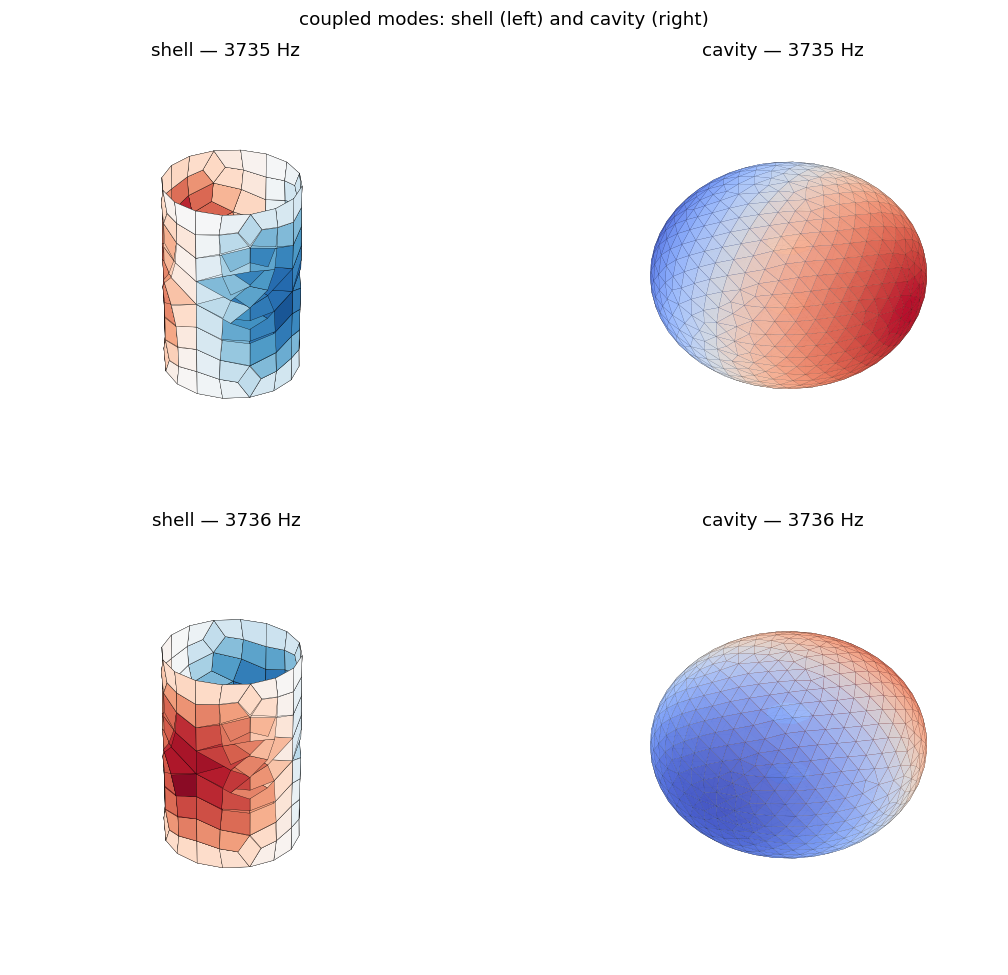

In [10]:
shell_conn0 = system["domains"]["structure"]["conn0"]
fluid_conn0 = system["domains"]["fluid"]["conn0"]

# Outer skin of the tetrahedral fluid: the faces owned by one element only,
# minus the ones wrapped around the shell.
from pycafe.build_matrices.coupling_nonconforming import (
    fluid_boundary_faces, wet_boundary,
)

faces, _owners = fluid_boundary_faces(fluid_conn0)
wet = wet_boundary(nodes, fluid_conn0, shell_conn0)
wet_keys = {tuple(sorted(f)) for f in wet["faces"]}
skin = [f for f in faces if tuple(sorted(f)) not in wet_keys]


def draw_shell(ax, w_red, title):
    """Left panel: the shell, coloured by radial displacement."""
    field = structural_displacement_field(w_red, blocks["idx_s"], nodes.shape[0])
    radial = np.zeros(nodes.shape[0])
    r = np.linalg.norm(nodes[:, :2], axis=1)
    unit = np.zeros_like(nodes)
    unit[r > 0, 0] = nodes[r > 0, 0] / r[r > 0]
    unit[r > 0, 1] = nodes[r > 0, 1] / r[r > 0]
    radial = np.real(np.einsum("ij,ij->i", np.real(field[:, :3]), unit))
    scale = np.abs(radial[np.unique(shell_conn0)]).max() or 1.0
    values = radial / scale

    polys = [nodes[face] for face in shell_conn0]
    colours = plt.cm.RdBu_r(0.5 + 0.5 * np.array(
        [values[face].mean() for face in shell_conn0]))
    ax.add_collection3d(Poly3DCollection(polys, facecolors=colours,
                                         edgecolor="k", linewidths=0.2))
    span = np.abs(nodes[np.unique(shell_conn0)]).max()
    ax.set(xlim=(-span, span), ylim=(-span, span), zlim=(-span, span))
    ax.set_title(title)
    ax.set_axis_off()


def draw_cavity(ax, p_full, title):
    """Right panel: the sphere skin, coloured by pressure."""
    p = np.real(p_full)
    scale = np.abs(p).max() or 1.0
    polys = [nodes[list(face)] for face in skin]
    colours = plt.cm.coolwarm(0.5 + 0.5 * np.array(
        [p[list(face)].mean() / scale for face in skin]))
    ax.add_collection3d(Poly3DCollection(polys, facecolors=colours,
                                         edgecolor="k", linewidths=0.05,
                                         alpha=0.9))
    span = np.abs(nodes).max()
    ax.set(xlim=(-span, span), ylim=(-span, span), zlim=(-span, span))
    ax.set_title(title)
    ax.set_axis_off()


flexible = np.where(f_coupled > 1.0)[0][:2]
fig = plt.figure(figsize=(11, 9))
for row, idx in enumerate(flexible):
    ax_s = fig.add_subplot(2, 2, 2 * row + 1, projection="3d")
    draw_shell(ax_s, modes[:ns, idx], f"shell — {f_coupled[idx]:.0f} Hz")
    ax_a = fig.add_subplot(2, 2, 2 * row + 2, projection="3d")
    draw_cavity(ax_a, expand_pressure(modes[ns:, idx], blocks["idx_a"],
                                      nodes.shape[0]),
                f"cavity — {f_coupled[idx]:.0f} Hz")
fig.suptitle("coupled modes: shell (left) and cavity (right)")
fig.tight_layout()
plt.show()

## 8. Forced response — direct against the coupled modal basis

A point force on the shell, swept through the band, solved twice: the full
coupled system at every frequency, and the same system projected on its coupled
modes. The interpolated coupling is carried through both without either solver
knowing how `Kc` was built.

direct    13.32 s   (150 frequencies, 3176 unknowns each)
modal      2.44 s   (400 coupled modes, reaching 36094 Hz)
speed-up   5.5 x   relative error 1.62%


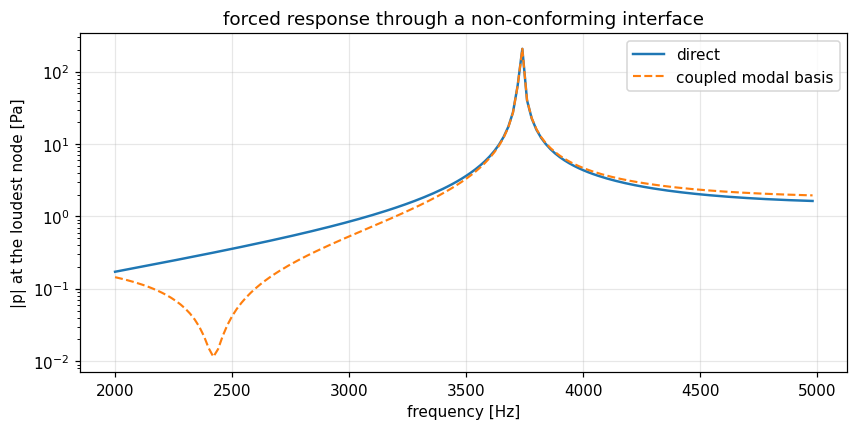

In [11]:
frequencies = np.arange(2000.0, 5000.0, 20.0)

# Radial unit force on a shell node halfway between the clamped ends.
shell_nodes0 = np.unique(shell_conn0)
drive = shell_nodes0[np.argmin(np.abs(nodes[shell_nodes0, 2]))]
F_s = np.zeros(blocks["n_s"])
dof = np.where(blocks["idx_s"] == 6 * drive + 0)[0]
F_s[dof] = 1.0

t0 = time.time()
direct = solve_vibroacoustic_frequency_sweep(
    system, frequencies, F_s=F_s, blocks=blocks, eta_s=0.02, verbose=False)
t_direct = time.time() - t0

# The rule of thumb -- a basis reaching 2 x f_max -- is about resonances
# *inside* the band. The force here sits on the shell, whose own resonances
# are far above the band, so the response is quasi-static in the structure
# and needs the modes above it: the basis has to go well beyond the rule.
# Measured on this model, at the probe node used below:
#
#     120 modes (to 20 kHz)   11.0 %
#     240 modes (to 28 kHz)    4.0 %
#     400 modes (to 36 kHz)    1.6 %
#
# 400 is what the number below asks for. The speed-up shrinks with it, and
# that trade is the content of this cell.
t0 = time.time()
basis = build_coupled_modal_basis(system, num_modes=400, blocks=blocks)
reduced = solve_coupled_modal_frequency_sweep(
    basis, frequencies, F_s=F_s, eta_s=0.02)
t_reduced = time.time() - t0

probe = int(np.argmax(np.abs(direct["p"]).max(axis=1)))
p_direct = np.abs(direct["p"][probe])
p_reduced = np.abs(reduced["p"][probe])
err = np.linalg.norm(p_reduced - p_direct) / np.linalg.norm(p_direct)

print(f"direct   {t_direct:6.2f} s   ({frequencies.size} frequencies, "
      f"{blocks['n_s'] + blocks['n_a']} unknowns each)")
print(f"modal    {t_reduced:6.2f} s   ({basis['freqs'].size} coupled modes, "
      f"reaching {basis['freqs'].max():.0f} Hz)")
print(f"speed-up {t_direct / t_reduced:5.1f} x   relative error {err:.2%}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(frequencies, p_direct, label="direct", lw=1.6)
ax.semilogy(frequencies, p_reduced, "--", label="coupled modal basis", lw=1.4)
ax.set(xlabel="frequency [Hz]", ylabel="|p| at the loudest node [Pa]",
       title="forced response through a non-conforming interface")
ax.grid(alpha=0.3)
ax.legend()
plt.show()


## 9. What this case is, and what it is not

**What it gives.** A geometry that no conforming mesh can carry — a curved
cavity around a shell — assembled and solved end to end. The two meshes are
each what their kernel needs, and the interface is reconciled by interpolation
instead of by shared nodes.

**What it costs.** On the box cavity, where both models exist, the coupled
frequencies of the split mesh sit within a fraction of a percent of the
conforming ones at equal density. That is the measured cost here, not a general
bound: the paper's sections 4.1 and 4.2 study how it grows with the ratio of
the two mesh sizes and with the curvature. A conforming mesh, where the
geometry allows one, stays the exact option and remains the default.

**What to check every time.** `consistency["relative_error"]` — a uniform
pressure must transfer unchanged. If it is not small, the two grids are too
different for the shape parameter in use, and `nonconforming={"shape": ...}`
widens or narrows the basis.

**What this model is not.** A demonstration of strong fluid–structure
interaction. Three things stand in the way, and all three are stated where they
occur rather than tuned away:

* the shell is meshed at 3 mm, coarse against its own bending wavelength, so
  the in-vacuo frequencies of section 6 are upper bounds — refining
  `structure_element_size` lowers them by tens of percent;
* the fluid mesh is sized for `F_MAX`, so the coupled frequencies printed above
  that figure are outside the resolved band;
* even with the shell brought into the cavity band, the coupling stays weak:
  the low-order modes of a small closed cylinder are nearly volume-preserving
  and, at $ka \approx 0.3$, barely load the surrounding air.

**What is still open.** The outer sphere is rigid here, so the cavity is
closed. Radiation into free space needs either an anechoic impedance on
`outer` or a PML layer, and neither is part of the coupled assembly yet —
`prepare_vibroacoustic_system` builds the two domains and the coupling, without
acoustic boundary conditions.
